## Topic: Simple Linear Regresion Code Implementation

### OUTCOMES
- 1. Load the placement dataset

- 2. Basic EDA

- 3. Train test split

- 4. Build Simple Linear Regression model

- 5. Evaluation of SLR

- 6. Prediction

In [1]:
# import necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


### 1. Load the placement dataset

In [2]:
# load -- Dataset
df = pd.read_csv("placement.csv")

df.head()

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57


### 2. Basic EDA

In [5]:
df.shape

(200, 2)

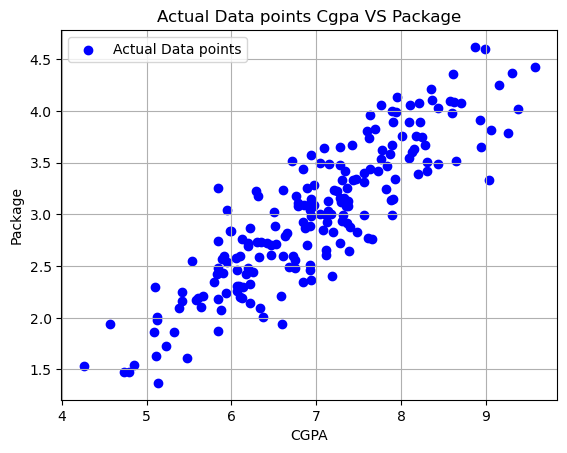

In [3]:
# plot or Visualzation of dataset 

plt.scatter(df["cgpa"], df['package'], color = 'blue', label = 'Actual Data points')

plt.title(f"Actual Data points Cgpa VS Package")
plt.xlabel("CGPA")
plt.ylabel("Package")

plt.legend()
plt.grid(True)
plt.show()

- Key NOTE:
    - for above data points are sorte of Linear
    - Decision for plot:
        - we can use Simple Linear Regression Model for thise data points
        - Becuase Data points are linear sorted and only one feature and targe.

### 3. Train test split

In [4]:
df.head(2)

,cgpa,package
0,6.89,3.26
1,5.12,1.98


In [8]:
# split

# Features
X = df.iloc[:, 0:1]

# target
y = df.iloc[:,-1]



In [10]:
X.head()

,cgpa
0,6.89
1,5.12
2,7.82
3,7.42
4,6.94


In [11]:
y.head()

0    3.26
1    1.98
2    3.25
3    3.67
4    3.57
Name: package, dtype: float64

In [12]:
# Train test split

# import library
from sklearn.model_selection import train_test_split

In [13]:
# split
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.2, random_state=2)

In [14]:
# shape
X_train.shape

(40, 1)

In [15]:
X_train.head()

,cgpa
50,9.58
52,8.37
80,7.63
185,6.31
121,6.50


In [17]:
y_train.head()

50     4.43
52     4.11
80     3.44
185    3.18
121    3.02
Name: package, dtype: float64

### 4. Build Simple Linear Regression model

In [18]:
# import library
from sklearn.linear_model import LinearRegression

In [19]:
# object of LinearRegression
lr = LinearRegression()

In [20]:
# Train the model
lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [21]:
## View the learned Parameters
# Weight or slop
lr.coef_

array([0.52263476])

In [22]:
# bias or intercept
lr.intercept_

np.float64(-0.6007624066050323)

### 5. Evaluation of SLR

In [27]:
# Evaluation on test data

# convert into 1-d
eval_package_value = X_test.iloc[1].values.reshape(1,1)

# Evaluation on test data
prediction_test_package = lr.predict(eval_package_value)

print(f"Model Predicted Package: {prediction_test_package}")


Model Predicted Package: [3.13607611]


c:\Users\kz\anaconda3\envs\myenv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [28]:
print("The Actual Package : ", y_test.iloc[1])

The Actual Package :  3.49


### Visualization of Best-fit-line

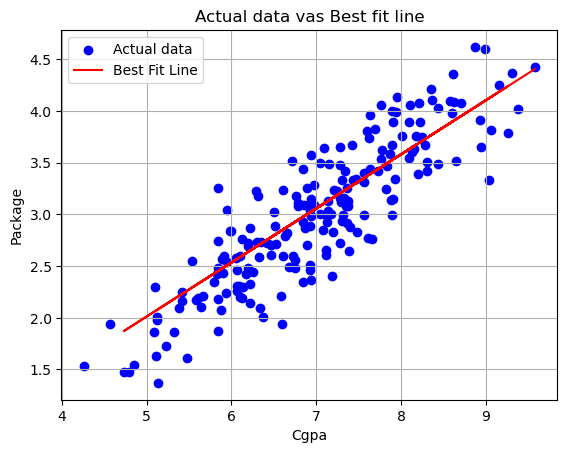

In [29]:

# Actual data vs Best Fit line

plt.scatter(df['cgpa'], df['package'], color= 'blue', label = 'Actual data')

plt.plot(X_train, lr.predict(X_train), color='red', label = 'Best Fit Line')

plt.title("Actual data vas Best fit line")
plt.xlabel("Cgpa")
plt.ylabel("Package")


plt.legend()
plt.grid(True)
plt.show()

In [31]:
df.head()

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57


### 6. Prediction

In [32]:
# Prediction for a New data
new_cgpa = np.array([[7.50]])

prediction_package = lr.predict(new_cgpa)

print(f"for new Cgpa {new_cgpa} the prediction Package: ", prediction_package)

for new Cgpa [[7.5]] the prediction Package:  [3.31899827]


c:\Users\kz\anaconda3\envs\myenv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
